In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
import pandas as pd
import os
from ipywidgets import interact, Dropdown
import seaborn as sns
import numpy as np

bushfire_data_file = '../data/final_bushfire_weather_data_natural.csv'
bushfire_data_file_all = '../data/final_bushfire_weather_data_all.csv'

In [2]:
# Read the bushfire data file and print to confirm

bushfire_df = pd.read_csv(bushfire_data_file)
bushfire_df_all = pd.read_csv(bushfire_data_file_all)

print(bushfire_df_all)
print(bushfire_df)

         fire_id discovery_date  discovery_month discovery_time  \
0              1     2005-02-02                2          13:00   
1              2     2004-05-12                5          08:45   
2              3     2004-05-31                5          19:21   
3              4     2004-06-28                6          16:00   
4              5     2004-06-28                6          16:00   
...          ...            ...              ...            ...   
1446853  2303562     2020-06-05                6          17:41   
1446854  2303563     2020-07-11                7          19:58   
1446855  2303564     2020-08-27                8          19:11   
1446856  2303565     2020-08-17                8          07:55   
1446857  2303566     2020-11-20               11          11:10   

         discovery_doy                               general_cause  \
0                   33  Power generation/transmission/distribution   
1                  133                                 

In [3]:
# Process data for visualisation
bushfire_df['discovery_date'] = pd.to_datetime(bushfire_df['discovery_date'], errors='coerce')

# Remove rows where t_max is smaller than TMIN
bushfire_df_cleaned = bushfire_df[bushfire_df['t_max'] >= bushfire_df['t_min']]

# Remove rows where t_max is hotter than the hottest recorded day in America (56.7°C)
bushfire_df_cleaned = bushfire_df[bushfire_df['t_max'] <= 56.7]

# Remove rows with temperatures below an extreme threshold (e.g., colder than -90°C)
bushfire_df_cleaned = bushfire_df[bushfire_df['t_max'] >= -90]

# Remove duplicates
bushfire_df_cleaned = bushfire_df.drop_duplicates()

# Print
print(f'Removed {len(bushfire_df) - len(bushfire_df_cleaned)} rows during cleaning')

# Update the df
bushfire_df = bushfire_df_cleaned

# Print
print(bushfire_df)

Removed 0 rows during cleaning
          fire_id discovery_date  discovery_month discovery_time  \
0            6882     2002-07-13                7          19:43   
1           42054     2002-08-19                8          14:00   
2           42055     2002-08-19                8          15:29   
3           42056     2002-08-21                8          12:10   
4           42057     2002-08-21                8          09:30   
...           ...            ...              ...            ...   
235312  400271211     2011-04-25                4          00:30   
235313  400271391     2011-06-09                6          21:00   
235314  400271392     2011-06-24                6          19:00   
235315  400280009     2011-07-23                7          17:00   
235316  400280010     2011-08-28                8          18:00   

        discovery_doy general_cause   origin  fire_size fire_class   latitude  \
0                 194       Natural  Natural       0.10          A  37.

In [4]:
# Process data for visualisation
bushfire_df_all['discovery_date'] = pd.to_datetime(bushfire_df_all['discovery_date'], errors='coerce')

# Remove rows where t_max is smaller than TMIN
bushfire_df_cleaned = bushfire_df_all[bushfire_df_all['t_max'] >= bushfire_df_all['t_min']]

# Remove rows where t_max is hotter than the hottest recorded day in America (56.7°C)
bushfire_df_cleaned = bushfire_df_all[bushfire_df_all['t_max'] <= 56.7]

# Remove rows with temperatures below an extreme threshold (e.g., colder than -90°C)
bushfire_df_cleaned = bushfire_df_all[bushfire_df_all['t_max'] >= -90]

# Remove duplicates
bushfire_df_cleaned = bushfire_df_all.drop_duplicates()

# Print
print(f'Removed {len(bushfire_df_all) - len(bushfire_df_cleaned)} rows during cleaning')

# Update the df
bushfire_df_all = bushfire_df_cleaned

# Print
print(bushfire_df_all)

Removed 0 rows during cleaning
         fire_id discovery_date  discovery_month discovery_time  \
0              1     2005-02-02                2          13:00   
1              2     2004-05-12                5          08:45   
2              3     2004-05-31                5          19:21   
3              4     2004-06-28                6          16:00   
4              5     2004-06-28                6          16:00   
...          ...            ...              ...            ...   
1446853  2303562     2020-06-05                6          17:41   
1446854  2303563     2020-07-11                7          19:58   
1446855  2303564     2020-08-27                8          19:11   
1446856  2303565     2020-08-17                8          07:55   
1446857  2303566     2020-11-20               11          11:10   

         discovery_doy                               general_cause  \
0                   33  Power generation/transmission/distribution   
1                  133  

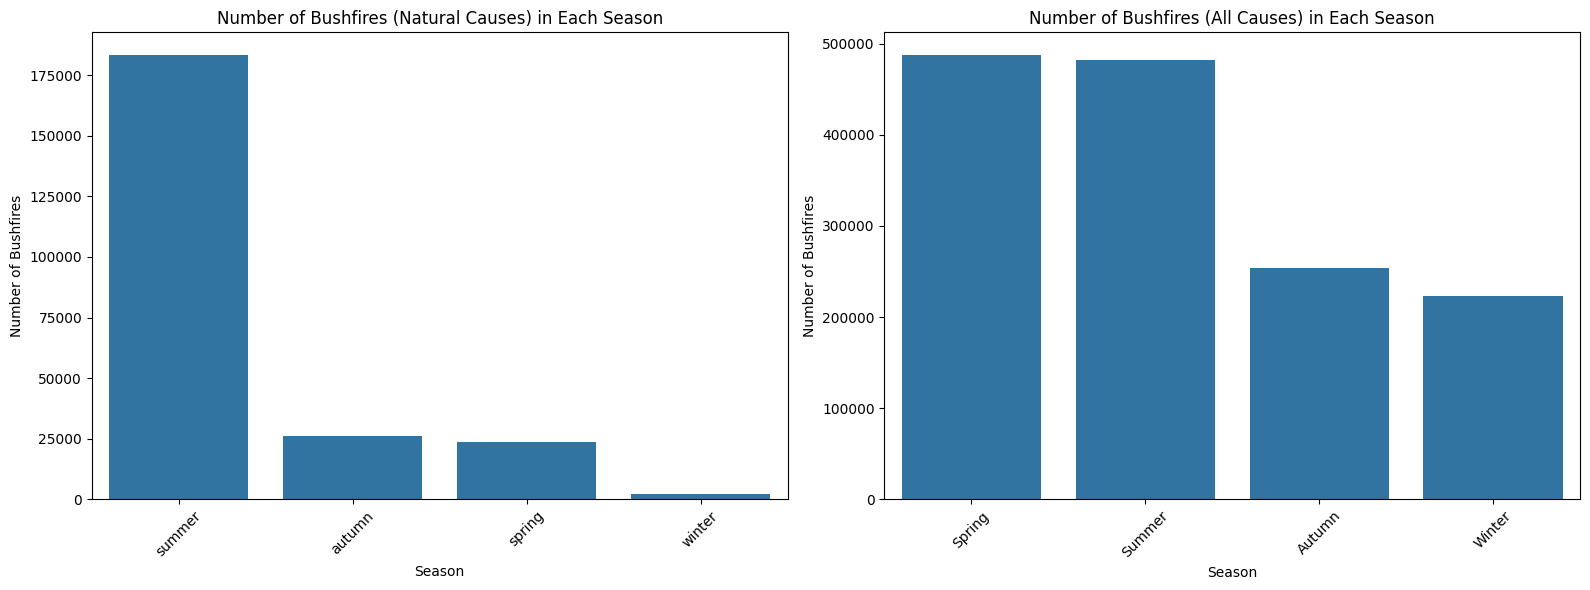

In [5]:
# PLOT THE NUMBER OF BUSHFIRES PER SEASON FOR NATURAL CAUSES ONLY

# Group and count by season
season_counts = bushfire_df['season'].value_counts()
season_counts_all = bushfire_df_all['season'].value_counts()

# Plotting two bar graphs side by side for comparison
plt.figure(figsize=(16, 6))

# Plot for Natural Causes
plt.subplot(1, 2, 1)
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title('Number of Bushfires (Natural Causes) in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Bushfires')
plt.xticks(rotation=45)

# Plot for All Causes
plt.subplot(1, 2, 2)
sns.barplot(x=season_counts_all.index, y=season_counts_all.values)
plt.title('Number of Bushfires (All Causes) in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Bushfires')
plt.xticks(rotation=45)

# Display the plots
plt.tight_layout()
plt.show()

In [6]:
# Function to plot number of bushfires per 2-degree increment of t_max, filtered by state
def plot_bushfires_by_temperature(state):
    if state == "All States":
        filtered_df = bushfire_df  # Use the dataset for all causes
    else:
        filtered_df = bushfire_df[bushfire_df['state'] == state]

    # Binning the t_max column into 2-degree increments from -21 to 57
    filtered_df['t_max_bins'] = pd.cut(filtered_df['t_max'], bins=np.arange(-21, 58, 2))

    # Count the number of bushfires in each temperature bin
    t_max_counts = filtered_df['t_max_bins'].value_counts().sort_index()

    # Remove bins where the count is zero
    t_max_counts = t_max_counts[t_max_counts > 0]

    # Create labels for the x-axis using the bin edges
    x_labels = [f"{int(interval.left)}-{int(interval.right)}°C" for interval in t_max_counts.index]

    # Plot the number of bushfires per 2-degree increment of t_max
    plt.figure(figsize=(18, 8))
    ax = sns.barplot(x=x_labels, y=t_max_counts.values, width=0.8)  # Set a width for the bars

    # Add counts on top of each bar (only where count is non-zero)
    for i, value in enumerate(t_max_counts.values):
        if value > 0:
            ax.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=8)

    # Titles and labels
    plt.title(f'Number of Bushfires (Natural) - {state}')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Number of Bushfires')

    # Adjust the x-axis limits to shift -20 near the origin
    plt.xlim(-1, len(x_labels))  # Set limits based on the number of bins

    plt.xticks(rotation=90)  # Rotate labels for better visibility

    plt.tight_layout()
    plt.show()

# Dropdown widget for state selection
state_dropdown = Dropdown(
    options=['All States'] + sorted(bushfire_df_all['state'].unique()),
    value='All States',
    description='State:'
)

# Use the interact function to update the plot when the dropdown changes
interact(plot_bushfires_by_temperature, state=state_dropdown)

interactive(children=(Dropdown(description='State:', options=('All States', 'AK', 'AL', 'AR', 'AZ', 'CA', 'CO'…

<function __main__.plot_bushfires_by_temperature(state)>

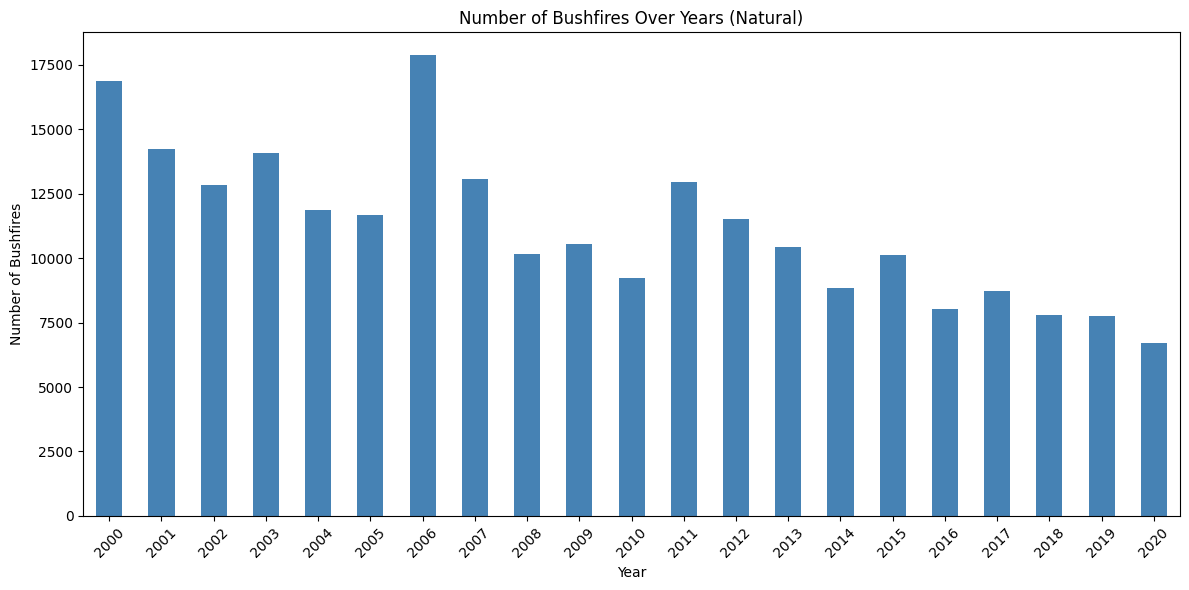

In [7]:
# Ensure 'discovery_date' is in datetime format
bushfire_df['discovery_date'] = pd.to_datetime(bushfire_df['discovery_date'])

# Extracting year from the discovery_date and grouping by year
daily_bushfires = bushfire_df.groupby(bushfire_df['discovery_date'].dt.year).size()

# Plotting as a bar graph
plt.figure(figsize=(12, 6))  # Adjusted the figure size for better readability
daily_bushfires.plot(kind='bar', color='steelblue')  # Set the color of the bars
plt.title('Number of Bushfires Over Years (Natural)')
plt.xlabel('Year')
plt.ylabel('Number of Bushfires')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


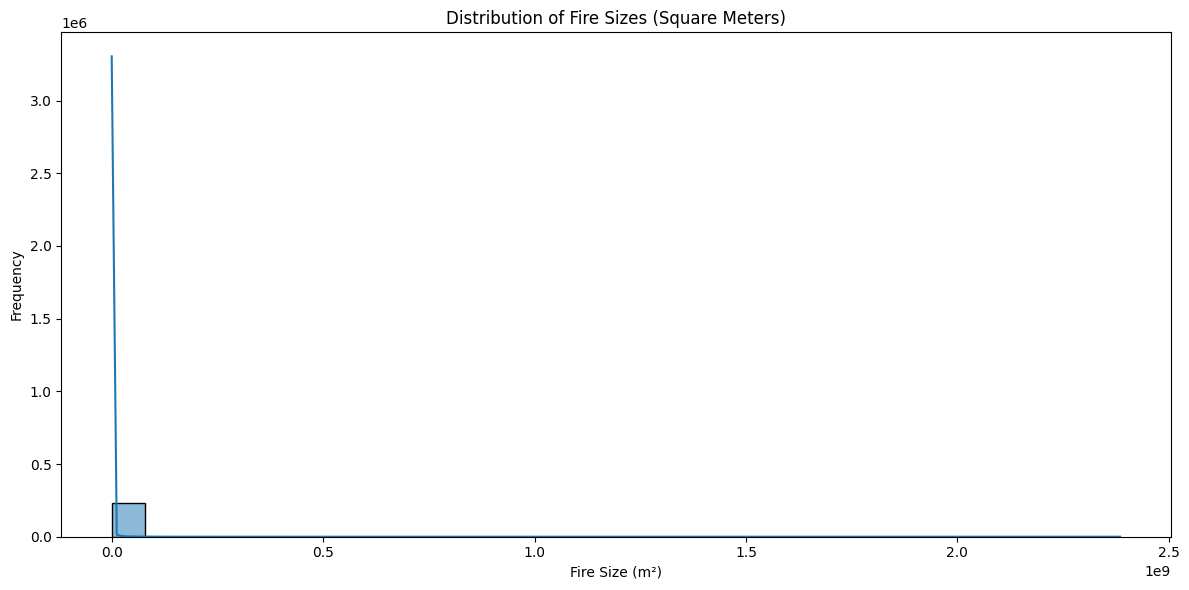

In [8]:
# Convert fire sizes from acres to square meters
bushfire_df['fire_size_sqm'] = bushfire_df['fire_size'] * 4046.86

# Histogram of fire sizes in square meters
plt.figure(figsize=(12, 6))  # Increased figure size for better readability
sns.histplot(bushfire_df['fire_size_sqm'], bins=30, kde=True)  # Adjusted bins for better spread
plt.title('Distribution of Fire Sizes (Square Meters)')
plt.xlabel('Fire Size (m²)')  # Updated x-axis label
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


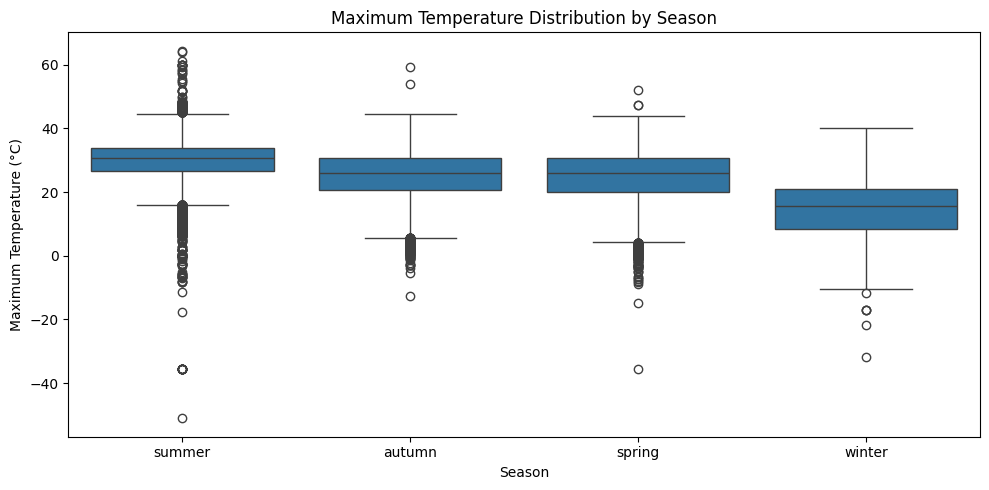

In [9]:
# Box plot of t_max by season
plt.figure(figsize=(10, 5))
sns.boxplot(x='season', y='t_max', data=bushfire_df)
plt.title('Maximum Temperature Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Maximum Temperature (°C)')
plt.tight_layout()
plt.show()


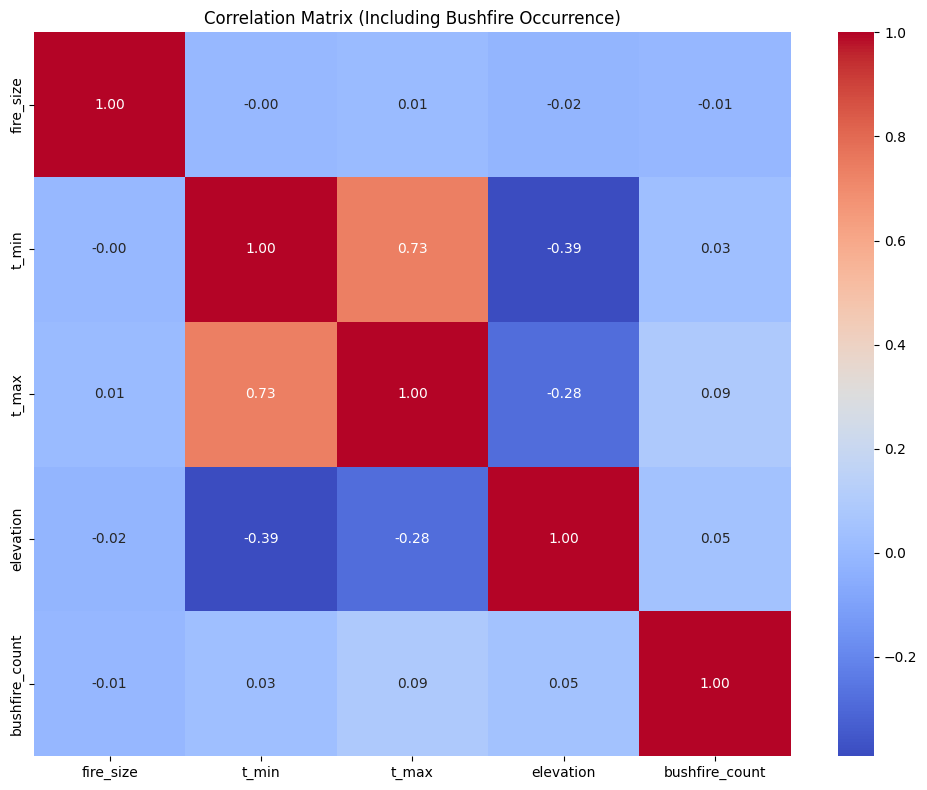

In [10]:
from sklearn.preprocessing import StandardScaler


# Create a new variable for bushfire occurrence by year
bushfire_df['year'] = pd.to_datetime(bushfire_df['discovery_date']).dt.year
bushfire_occurrence = bushfire_df['year'].value_counts().reset_index()
bushfire_occurrence.columns = ['year', 'bushfire_count']

# Merge occurrence back into the original DataFrame
bushfire_df = bushfire_df.merge(bushfire_occurrence, on='year', how='left')

# Selecting relevant columns for correlation
data_to_correlate = bushfire_df[['fire_size', 't_min', 't_max', 'elevation', 'bushfire_count']]

# Standardizing the data
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data_to_correlate)

# Create a DataFrame from the standardized data
standardized_df = pd.DataFrame(standardized_data, columns=data_to_correlate.columns)

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(standardized_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Including Bushfire Occurrence)')
plt.tight_layout()
plt.show()

In [11]:
# creates a map with bushfire locations

import folium
from folium.plugins import MarkerCluster

# Create a base map centered at an appropriate location
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)  # Coordinates for the center of the U.S.

# Initialize a Marker Cluster
marker_cluster = MarkerCluster().add_to(m)

# Add bushfire locations as CircleMarkers to the cluster
for idx, row in bushfire_df.iterrows():
    folium.CircleMarker(
        location=(row['latitude'], row['longitude']),
        radius=5,  # Size of the marker
        color='blue',  # All causes are natural, use one color
        fill=True,
        fill_color='blue',  # Use blue for the fill color
        fill_opacity=0.6,
        popup=f"Fire ID: {row['fire_id']}, Size: {row['fire_size']} acres"  # Popup for more info
    ).add_to(marker_cluster)  # Add to the Marker Cluster

# Save the map to an HTML file
m.save('bushfires_map.html')
